In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [94]:
plt.figure(figsize= (10,6))
sns.set(style="whitegrid")

<Figure size 1000x600 with 0 Axes>

In [95]:
df = pd.read_csv("demand_forecasting.csv")

In [96]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [97]:
df["Epidemic"].value_counts()

Epidemic
0    60800
1    15200
Name: count, dtype: int64

In [98]:
df.dtypes

Date                   object
Store ID               object
Product ID             object
Category               object
Region                 object
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Price                 float64
Discount                int64
Weather Condition      object
Promotion               int64
Competitor Pricing    float64
Seasonality            object
Epidemic                int64
Demand                  int64
dtype: object

In [99]:
df["Date"] = pd.to_datetime(df["Date"])

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                76000 non-null  datetime64[ns]
 1   Store ID            76000 non-null  object        
 2   Product ID          76000 non-null  object        
 3   Category            76000 non-null  object        
 4   Region              76000 non-null  object        
 5   Inventory Level     76000 non-null  int64         
 6   Units Sold          76000 non-null  int64         
 7   Units Ordered       76000 non-null  int64         
 8   Price               76000 non-null  float64       
 9   Discount            76000 non-null  int64         
 10  Weather Condition   76000 non-null  object        
 11  Promotion           76000 non-null  int64         
 12  Competitor Pricing  76000 non-null  float64       
 13  Seasonality         76000 non-null  object    

In [101]:
df.isna().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

In [102]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
75995    False
75996    False
75997    False
75998    False
75999    False
Length: 76000, dtype: bool

In [103]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,76000,2023-01-15 12:00:00,2022-01-01 00:00:00,2022-07-09 18:00:00,2023-01-15 12:00:00,2023-07-24 06:00:00,2024-01-30 00:00:00,NaN
Inventory Level,76000.0,301.062842,0.0,136.0,227.0,408.0,2267.0,226.510161
Units Sold,76000.0,88.827316,0.0,58.0,84.0,114.0,426.0,43.994525
Units Ordered,76000.0,89.090645,0.0,0.0,0.0,121.0,1616.0,162.404627
Price,76000.0,67.726028,4.74,31.9975,64.5,95.83,228.03,39.377899
Discount,76000.0,9.087039,0.0,5.0,10.0,10.0,25.0,7.475781
Promotion,76000.0,0.328947,0.0,0.0,0.0,1.0,1.0,0.469834
Competitor Pricing,76000.0,69.454029,4.29,32.62,65.7,97.9325,261.22,40.943818
Epidemic,76000.0,0.2,0.0,0.0,0.0,0.0,1.0,0.400003
Demand,76000.0,104.317158,4.0,71.0,100.0,133.0,430.0,46.964801


In [104]:
df.describe(include= "object").T

,count,unique,top,freq
Store ID,76000,5,S001,15200
Product ID,76000,20,P0001,3800
Category,76000,5,Groceries,30400
Region,76000,4,North,30400
Weather Condition,76000,4,Cloudy,24360
Seasonality,76000,4,Winter,21000


In [105]:
df.head(2)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229


In [106]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

In [107]:
df["Day"] = df["Date"].dt.day
df["Weekday"] = df["Date"].dt.day_name()

In [108]:
df["Discounted Price"] = df["Price"] * (1- df["Discount"] / 100)

In [109]:
df.head(10)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Weekday,Discounted Price
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,0,85.73,Winter,0,115,2022,1,1,Saturday,69.0840
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,1,92.02,Winter,0,229,2022,1,1,Saturday,68.1360
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,1,60.08,Winter,0,157,2022,1,1,Saturday,56.6460
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,0,85.19,Winter,0,52,2022,1,1,Saturday,78.8670
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,0,51.63,Winter,0,59,2022,1,1,Saturday,54.4100
5,2022-01-01,S001,P0006,Toys,North,209,60,0,35.53,0,...,0,40.01,Winter,0,55,2022,1,1,Saturday,35.5300
6,2022-01-01,S001,P0007,Groceries,North,118,81,335,23.27,5,...,0,24.78,Winter,0,94,2022,1,1,Saturday,22.1065
7,2022-01-01,S001,P0008,Electronics,North,244,42,0,37.79,5,...,0,44.85,Winter,0,61,2022,1,1,Saturday,35.9005
8,2022-01-01,S001,P0009,Clothing,North,115,88,139,94.20,5,...,0,108.70,Winter,0,129,2022,1,1,Saturday,89.4900
9,2022-01-01,S001,P0010,Furniture,North,192,70,300,113.35,10,...,0,129.98,Winter,0,69,2022,1,1,Saturday,102.0150


In [110]:
print(df["Date"].head(10))
print(df["Date"].dtype)
print(df["Date"].nunique())
print(df["Date"].min(), df["Date"].max())

0   2022-01-01
1   2022-01-01
2   2022-01-01
3   2022-01-01
4   2022-01-01
5   2022-01-01
6   2022-01-01
7   2022-01-01
8   2022-01-01
9   2022-01-01
Name: Date, dtype: datetime64[ns]
datetime64[ns]
760
2022-01-01 00:00:00 2024-01-30 00:00:00


In [111]:
df["Sell Through Rate"] = df["Units Sold"] / df["Inventory Level"]

In [112]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Weekday,Discounted Price,Sell Through Rate
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,85.73,Winter,0,115,2022,1,1,Saturday,69.084,0.523077
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,92.02,Winter,0,229,2022,1,1,Saturday,68.136,1.000000
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,60.08,Winter,0,157,2022,1,1,Saturday,56.646,0.461538
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,85.19,Winter,0,52,2022,1,1,Saturday,78.867,0.323741
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,51.63,Winter,0,59,2022,1,1,Saturday,54.410,0.427632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,...,32.23,Winter,0,64,2024,1,30,Tuesday,28.310,0.270386
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,...,40.73,Winter,0,137,2024,1,30,Tuesday,40.774,0.839416
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,...,19.41,Winter,0,68,2024,1,30,Tuesday,16.029,0.223350
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,...,143.71,Winter,0,84,2024,1,30,Tuesday,151.720,0.464000


In [113]:
df["Sell Through Rate"].describe()

count    75594.000000
mean         0.437580
std          0.298007
min          0.003150
25%          0.190807
50%          0.350475
75%          0.642276
max          1.000000
Name: Sell Through Rate, dtype: float64

In [114]:
df.groupby("Category")["Demand"].agg(["mean","sum", "std"]).sort_values(by = "sum",ascending = False).reset_index()

,Category,mean,sum,std
0,Groceries,120.976447,3677684,48.362730
1,Clothing,112.619737,1369456,41.022968
2,Furniture,73.581140,1006590,32.336141
3,Toys,92.606955,985338,46.170390
4,Electronics,97.482018,889036,40.557859


In [115]:
df.groupby(["Region", "Seasonality"])["Demand"].mean()

Region  Seasonality
East    Autumn         106.353297
        Spring         100.168478
        Summer         115.388315
        Winter         104.273571
North   Autumn         103.065797
        Spring          97.399457
        Summer         112.843750
        Winter         102.017738
South   Autumn         104.464560
        Spring         100.328804
        Summer         115.089946
        Winter         107.733095
West    Autumn         100.165385
        Spring          93.219293
        Summer         108.111141
        Winter         100.988810
Name: Demand, dtype: float64

In [116]:
df.groupby("Promotion")["Demand"].mean()

Promotion
0     95.026843
1    123.269400
Name: Demand, dtype: float64

In [117]:
pd.pivot_table(df, values="Demand", index= "Month", columns= "Category", aggfunc="mean")

Category,Clothing,Electronics,Furniture,Groceries,Toys
Month,,,,,
1,126.997962,99.519022,75.690821,117.399457,94.242236
2,128.966518,84.184524,61.625992,103.522768,68.885204
3,105.835685,108.120968,84.015233,126.561694,128.273041
4,106.972917,85.916667,63.005556,105.111250,85.753571
5,108.650202,79.577957,56.036738,98.637903,71.756912
6,105.670833,106.922222,79.908333,147.772500,100.825000
7,107.838710,87.418011,66.156810,128.744355,74.366359
8,107.871976,109.733871,83.524194,149.875403,102.794931
9,105.118750,105.015278,81.854630,122.239167,102.722619


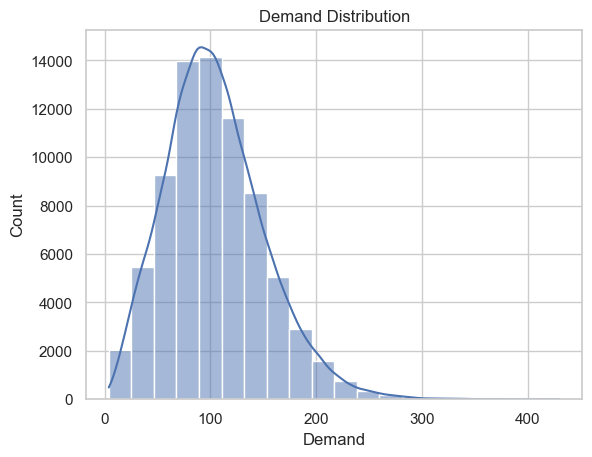

In [118]:
sns.histplot(df["Demand"], bins = 20, kde = True)
plt.title("Demand Distribution")
plt.show()

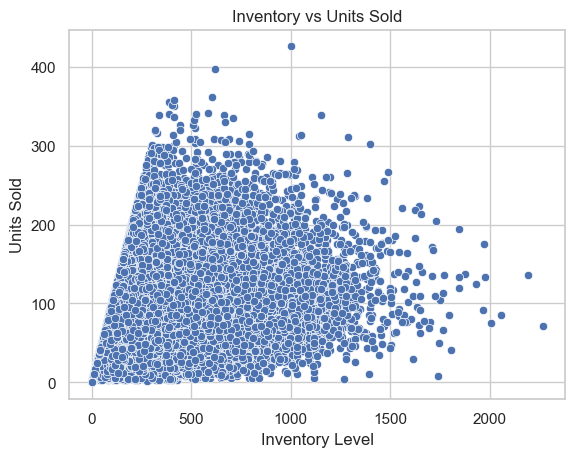

In [119]:
sns.scatterplot(data = df, x = "Inventory Level", y = "Units Sold")
plt.title("Inventory vs Units Sold")
plt.show()

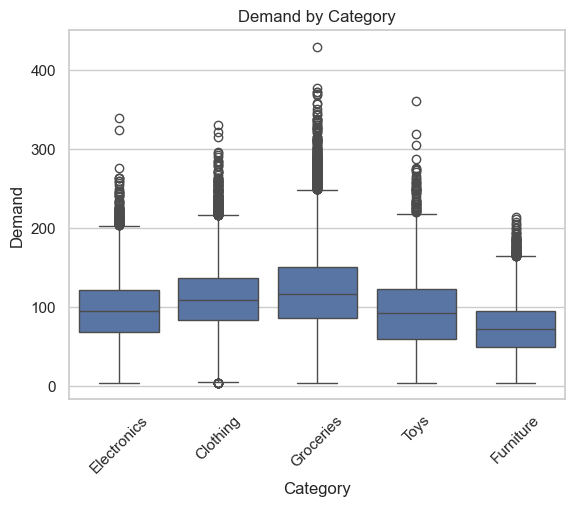

In [120]:
sns.boxplot(data = df, x = "Category", y = "Demand")
plt.xticks(rotation = 45)
plt.title("Demand by Category")
plt.show()

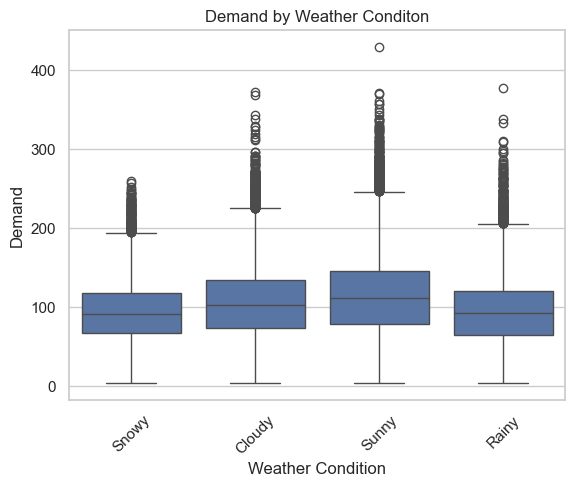

In [124]:
sns.boxplot(data = df, x = "Weather Condition", y = "Demand")
plt.xticks(rotation = 45)
plt.title("Demand by Weather Conditon")
plt.show()

In [125]:
monthly_demand = df.groupby("Month")["Demand"].mean()

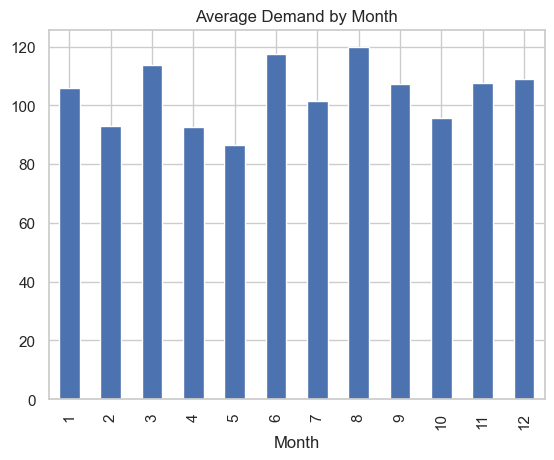

In [126]:
monthly_demand.plot(kind = "bar")
plt.title("Average Demand by Month")
plt.show()

In [130]:
daily_demand = df.groupby("Date")["Demand"].sum()

In [131]:
daily_demand

Date
2022-01-01    10060
2022-01-02    10814
2022-01-03    11317
2022-01-04    11469
2022-01-05    11724
              ...  
2024-01-26    11182
2024-01-27    11540
2024-01-28    11440
2024-01-29    10268
2024-01-30     9657
Name: Demand, Length: 760, dtype: int64

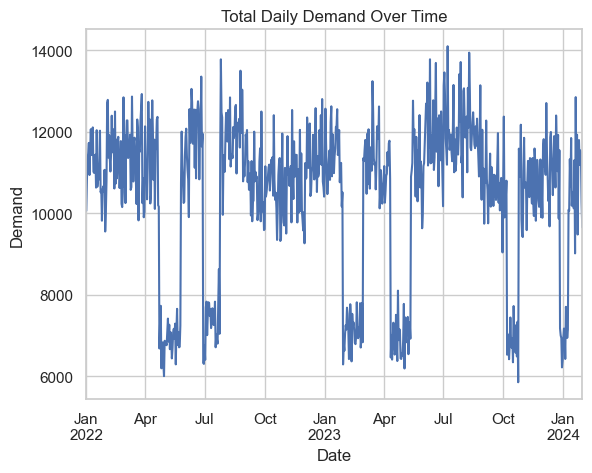

In [132]:
daily_demand.plot()
plt.title("Total Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.show()

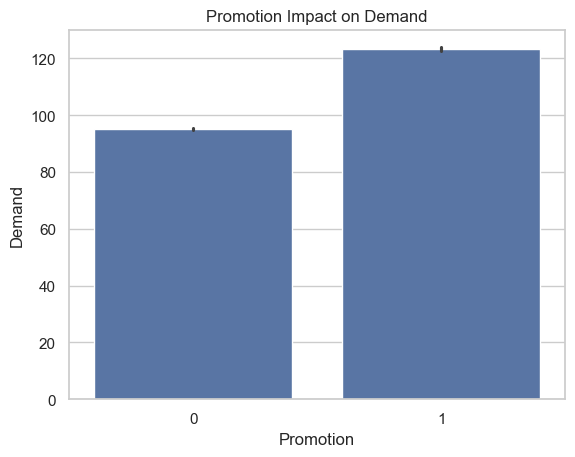

In [135]:
sns.barplot(data = df, x="Promotion", y = "Demand")
plt.title("Promotion Impact on Demand")
plt.show()

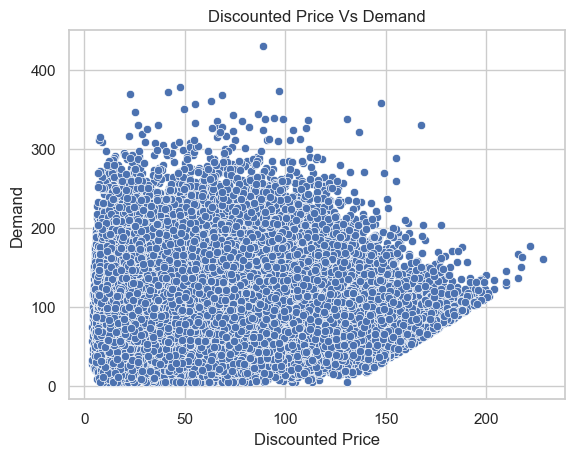

In [137]:
sns.scatterplot(data= df, x="Discounted Price", y="Demand")
plt.title("Discounted Price Vs Demand")
plt.show()

<Axes: title={'center': 'Demand by Seaonality'}, xlabel='Seasonality'>

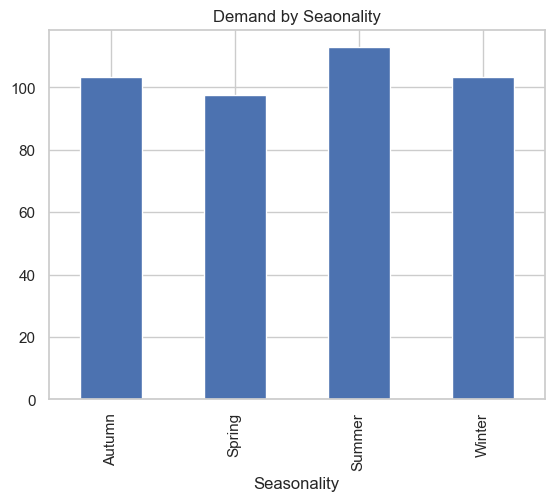

In [138]:
df.groupby("Seasonality")["Demand"].mean().plot(kind ="bar", title = "Demand by Seaonality")

<Axes: title={'center': 'Epidemic Impact on Demand'}, xlabel='Epidemic'>

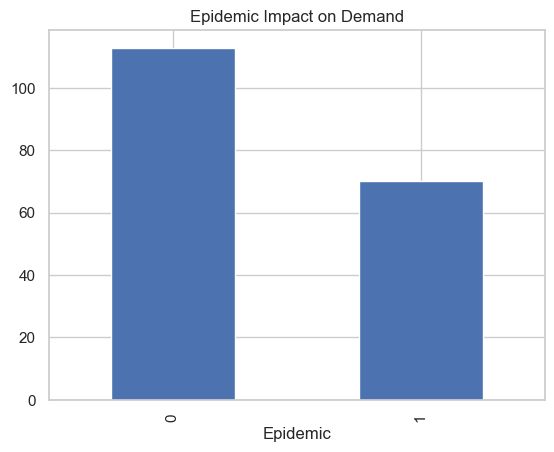

In [139]:
df.groupby("Epidemic")["Demand"].mean().plot(kind ="bar", title = "Epidemic Impact on Demand")

In [140]:
df.to_csv("preprocessed_demand_forecasting_data.csv")